# Objective

Notebook này được thực hiện nhằm tìm hiểu và xây dựng **mô hình Transformer** cho bài toán **Image Captioning** trên một **tập dữ liệu nhỏ**.  
Image Captioning là bài toán kết hợp giữa **Thị giác máy tính (Computer Vision)** và **Xử lý ngôn ngữ tự nhiên (NLP)**, trong đó mô hình cần hiểu nội dung của ảnh và sinh ra một câu mô tả phù hợp.

Mục tiêu của notebook:
- Hiểu cách hoạt động cơ bản của Transformer.
- Áp dụng Transformer vào bài toán Image Captioning.
- Thực hiện đầy đủ các bước: tiền xử lý dữ liệu, xây dựng mô hình, huấn luyện và đánh giá.
- Làm quen với việc triển khai một mô hình kết hợp CNN và Transformer trong thực tế.

**Transformer** là một kiến trúc Deep Learning được sử dụng nhiều trong các bài toán xử lý chuỗi, đặc biệt là NLP.  
So với các mô hình truyền thống như RNN hay LSTM, Transformer không xử lý tuần tự từng bước mà sử dụng cơ chế Attention, nhờ đó có thể huấn luyện song song và học được mối quan hệ giữa các từ ở xa nhau trong câu.

Một số mô hình nổi tiếng dựa trên Transformer là BERT và GPT.

## Các thành phần chính của Transformer

### Input Embedding
Mỗi từ trong câu được chuyển thành một vector số.  
Việc nhúng từ giúp mô hình học được mối quan hệ ngữ nghĩa giữa các từ trong câu.

### Positional Encoding
Do Attention không tự nhận biết thứ tự của từ trong câu, nên cần thêm thông tin về vị trí của từng từ.  
Trong mô hình này, positional encoding được sử dụng dưới dạng cố định (non-trainable).

### Multi-Head Attention
Cơ chế attention cho phép mô hình tập trung vào những từ quan trọng trong câu.  
Việc sử dụng nhiều head giúp mô hình học được nhiều mối quan hệ khác nhau giữa các từ cùng lúc.

### Mask
Mask được sử dụng để:
- Không cho mô hình nhìn thấy các từ ở tương lai khi đang sinh câu
- Bỏ qua các token `<pad>` trong quá trình huấn luyện

### Cross-Attention
Trong bài toán Image Captioning, decoder cần chú ý đến đặc trưng ảnh do encoder tạo ra.  
Cross-attention giúp decoder kết hợp thông tin từ ảnh và các từ đã sinh để dự đoán từ tiếp theo.

# Methodology

## 1) Dữ liệu và Tiền xử lý

Tập dữ liệu **Flickr30k** được sử dụng, trong đó mỗi ảnh có 5 câu mô tả khác nhau.

Các bước tiền xử lý gồm:
- Chuẩn hoá caption: chuyển về chữ thường, loại bỏ ký tự không cần thiết
- Lọc các caption có độ dài quá ngắn hoặc quá dài
- Chia dữ liệu thành tập train, validation và test
- Tiền xử lý ảnh: decode ảnh, resize về kích thước chuẩn, chuẩn hoá theo mô hình CNN

Dữ liệu được xử lý bằng **TensorFlow Dataset** với các bước:
- shuffle
- map
- batch
- prefetch  
nhằm tăng tốc quá trình huấn luyện.

## 2) Kiến trúc mô hình

Mô hình được xây dựng gồm ba phần chính:

### CNN Feature Extractor
Sử dụng **EfficientNetB0** đã được huấn luyện trước để trích xuất đặc trưng từ ảnh đầu vào.

### Transformer Encoder
Encoder nhận đặc trưng ảnh từ CNN và xử lý thông qua các lớp để tạo ra biểu diễn phù hợp cho decoder.

### Transformer Decoder
Decoder nhận:
- Caption đầu vào
- Đầu ra của encoder (đặc trưng ảnh)

Decoder bao gồm:
- Positional Embedding
- Masked Multi-Head Attention
- Cross-Attention
- Feed Forward Network
- Layer Normalization

Lớp cuối cùng là **Dense + Softmax** để dự đoán từ tiếp theo trong từ vựng.

## 3) Huấn luyện mô hình

Trong quá trình huấn luyện:
- Ảnh được đưa vào encoder
- Caption đầu vào cho decoder là `caption[:, :-1]` (loại bỏ token `<end>`)
- Nhãn mục tiêu là `caption[:, 1:]` (loại bỏ token `<start>`)

Mục tiêu của quá trình huấn luyện là giảm giá trị **loss**, giúp mô hình dự đoán chính xác từ tiếp theo trong câu mô tả.

## 4) Suy luận và Đánh giá

Trong quá trình huấn luyện, **Sparse Categorical Crossentropy** được sử dụng làm hàm loss.

Khi sinh caption cho ảnh mới, mô hình sử dụng **Greedy Decoding**, trong đó ở mỗi bước sẽ chọn từ có xác suất cao nhất.  
Kết quả sinh ra được đánh giá bằng **BLEU score** trên tập test.

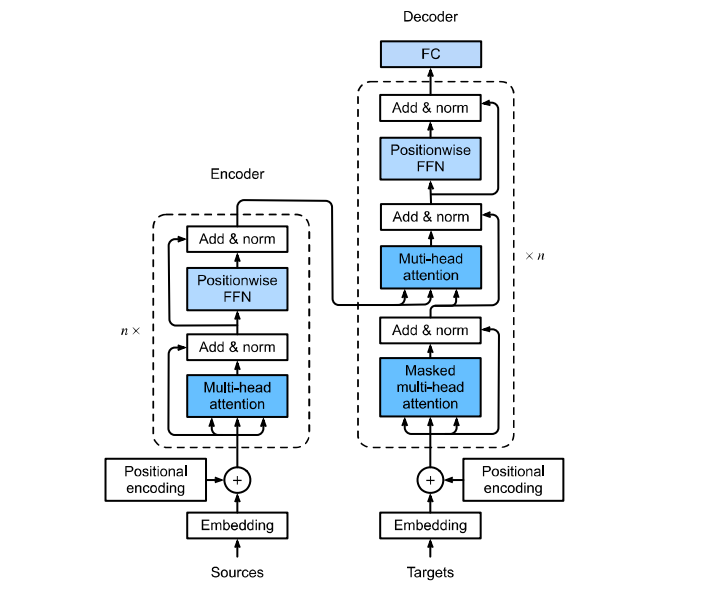

## Library setup

In [2]:
# =====================================================
# Library Setup
# =====================================================
# Cell này dùng để:
# - Import các thư viện cần thiết cho bài toán Image Captioning
# - Giảm bớt log/warning của TensorFlow để output gọn gàng
# - Chuẩn bị môi trường ổn định trước khi xây dựng mô hình

import os
import warnings

# Giảm log C++ của TensorFlow
# Mức 3: chỉ hiện ERROR (ẩn INFO và WARNING)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Tắt tự động JIT/XLA để tránh log "register cuDNN/cuBLAS"
# Không ảnh hưởng đến việc train mô hình
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

# Ẩn warning Python thông thường
warnings.filterwarnings("ignore")

# -----------------------------------------------------
# Import TensorFlow và Keras
# -----------------------------------------------------
# Sử dụng tf.keras để tránh xung đột version
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# EfficientNetB0: CNN pretrained dùng để trích xuất đặc trưng ảnh
from tensorflow.keras.applications import efficientnet

# TextVectorization: chuyển caption -> token id
# (bao gồm lowercase, tách từ, padding/cắt độ dài)
from tensorflow.keras.layers import TextVectorization

# Giảm log Python-level của TensorFlow
tf.get_logger().setLevel("ERROR")

# -----------------------------------------------------
# Các thư viện hỗ trợ khác
# -----------------------------------------------------
import re                      # xử lý chuỗi caption (regex)
import numpy as np             # xử lý mảng số
import matplotlib.pyplot as plt # hiển thị ảnh, vẽ loss

from sklearn.model_selection import train_test_split

# BLEU score để đánh giá chất lượng caption sinh ra
from nltk.translate.bleu_score import corpus_bleu

# tqdm: hiển thị progress bar khi train/inference
from tqdm.auto import tqdm

# -----------------------------------------------------
# Set seed (khuyến nghị)
# -----------------------------------------------------
# Giúp kết quả giữa các lần chạy không chênh lệch quá nhiều
SEED = 111
keras.utils.set_random_seed(SEED)

# Bật chế độ deterministic nếu môi trường hỗ trợ
# Nếu không hỗ trợ thì bỏ qua, không ảnh hưởng tới code
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Hoàn thành!")


Hoàn thành!


# Configuration

In [3]:
# =====================================================
# 2) Configuration (PATH + Hyperparameters)
# =====================================================
# Cell này dùng để:
# - Khai báo đường dẫn dữ liệu trên Kaggle
# - Đặt các tham số quan trọng để dễ chỉnh khi thử nghiệm
# Lưu ý: Cell này CHỈ cấu hình, chưa load ảnh / chưa train gì cả.

import os

# -------------------------
# (1) Dataset paths (Kaggle)
# -------------------------


IMAGES_PATH = "/kaggle/input/flickr-image-dataset/flickr30k_images/flickr30k_images"
CAPTIONS_PATH = "/kaggle/input/results/results_final_vietnamese.csv"

# Kiểm tra nhanh để tránh lỗi "file not found" về sau
print("IMAGES_PATH exists:", os.path.exists(IMAGES_PATH))
print("CAPTIONS_PATH exists:", os.path.exists(CAPTIONS_PATH))

# Nếu 1 trong 2 dòng trên là False:
# - Bạn vào tab "Data" của Kaggle Notebook
# - xem đúng tên dataset + đúng folder bên trong rồi chỉnh lại 2 đường dẫn trên

# -------------------------
# (2) Training parameters
# -------------------------
# IMAGE_SIZE: kích thước ảnh đưa vào EfficientNetB0 (hay dùng 224 hoặc 299)
# - Nếu notebook bạn đang dùng 299 thì giữ 299 để đồng bộ.
IMAGE_SIZE = (299, 299)

# SEQ_LENGTH: độ dài tối đa của caption (token)
# - Câu dài hơn sẽ bị cắt, câu ngắn hơn sẽ được pad
SEQ_LENGTH = 25

# VOCAB_SIZE: kích thước từ vựng (càng lớn càng nhiều từ, nhưng model nặng hơn)
VOCAB_SIZE = 15000

# BATCH_SIZE: Kaggle GPU thường ổn với 128/256 tùy RAM
# - Nếu bị OOM thì hạ xuống 64 hoặc 128
BATCH_SIZE = 64

# EPOCHS: số epoch train
EPOCHS = 30

# -------------------------
# (3) Transformer parameters
# -------------------------
# EMBED_DIM: kích thước embedding cho token (NLP)
# FF_DIM: kích thước hidden trong feed-forward network
# NUM_HEADS: số head trong multi-head attention

EMBED_DIM = 256
FF_DIM = 256
NUM_HEADS = 4

print("Config loaded:")
print(" - IMAGE_SIZE:", IMAGE_SIZE)
print(" - SEQ_LENGTH:", SEQ_LENGTH)
print(" - VOCAB_SIZE:", VOCAB_SIZE)
print(" - BATCH_SIZE:", BATCH_SIZE)
print(" - EPOCHS:", EPOCHS)
print(" - EMBED_DIM:", EMBED_DIM, "| FF_DIM:", FF_DIM, "| NUM_HEADS:", NUM_HEADS)


IMAGES_PATH exists: True
CAPTIONS_PATH exists: True
Config loaded:
 - IMAGE_SIZE: (299, 299)
 - SEQ_LENGTH: 25
 - VOCAB_SIZE: 15000
 - BATCH_SIZE: 64
 - EPOCHS: 30
 - EMBED_DIM: 256 | FF_DIM: 256 | NUM_HEADS: 4


In [4]:
# =====================================================
# 3) Load & Preprocess Captions
# =====================================================
# Cell này dùng để:
# - Đọc file caption (results.csv)
# - Chuẩn hoá caption (lowercase, bỏ ký tự đặc biệt)
# - Lọc caption theo độ dài
# - Gom dữ liệu về dạng {image_name: [list captions]}

import pandas as pd
captions_df = pd.read_csv(CAPTIONS_PATH, sep="|")

# Xem nhanh vài dòng đầu để kiểm tra
print("Chú thích mẫu:")
captions_df.head()


Chú thích mẫu:


,image_name,comment_number,comment
0,1000092795.jpg,0,Hai chàng trai trẻ với mái tóc bù xù nhìn vào ...
1,1000092795.jpg,1,"Hai con đực trẻ, da trắng đang ở bên ngoài gần..."
2,1000092795.jpg,2,Hai người đàn ông mặc áo xanh đang đứng trong ...
3,1000092795.jpg,3,Một người đàn ông mặc áo xanh đứng trong vườn.
4,1000092795.jpg,4,Hai người bạn tận hưởng thời gian bên nhau.


# Chuẩn hóa caption

In [5]:
# =====================================================
# 4) Normalize Vietnamese Captions
# =====================================================
# Cell này dùng để:
# - Chuẩn hoá caption tiếng Việt (giữ dấu)
# - Thêm token <start> và <end>
# - Lọc caption theo độ dài SEQ_LENGTH
# - Gom caption theo từng ảnh

from collections import defaultdict
captions_df.columns = captions_df.columns.str.strip()

# -------------------------
# (1) Hàm chuẩn hoá caption
# -------------------------
def normalize_caption(text):
    """
    Chuẩn hoá caption tiếng Việt:
    - chuyển về chữ thường
    - loại ký tự đặc biệt
    - chuẩn hoá khoảng trắng
    """
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text, flags=re.UNICODE)

    # Chuẩn hoá khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()

    return text

# -------------------------
# (2) Gom caption theo từng ảnh
# -------------------------
image_captions = defaultdict(list)

for _, row in captions_df.iterrows():
    # Tên file ảnh
    image_name = str(row["image_name"]).strip()

    # Caption tiếng Việt
    caption = str(row["comment"]).strip()

    # Chuẩn hoá caption
    caption = normalize_caption(caption)

    # Thêm token bắt đầu/kết thúc để decoder học cách sinh câu
    caption = f"<start> {caption} <end>"

    # Lọc caption theo độ dài (tính theo số token tách bởi khoảng trắng)
    if len(caption.split()) <= SEQ_LENGTH:
        image_captions[image_name].append(caption)

# -------------------------
# (3) Kiểm tra nhanh kết quả
# -------------------------
print("Số lượng ảnh", len(image_captions))

sample_image = next(iter(image_captions))
print("\n Ví dụ:")
print("Image:", sample_image)

for cap in image_captions[sample_image][:5]:
    print(" -", cap)


Số lượng ảnh 31768

 Ví dụ:
Image: 1000092795.jpg
 - <start> hai chàng trai trẻ với mái tóc bù xù nhìn vào tay mình khi đi chơi ngoài sân <end>
 - <start> hai con đực trẻ da trắng đang ở bên ngoài gần nhiều bụi cây <end>
 - <start> hai người đàn ông mặc áo xanh đang đứng trong sân <end>
 - <start> một người đàn ông mặc áo xanh đứng trong vườn <end>
 - <start> hai người bạn tận hưởng thời gian bên nhau <end>


# TextVectorization

In [7]:
# =====================================================
# 5) TextVectorization (Caption -> Token IDs)
# =====================================================
# Cell này dùng để:
# - Tạo bộ từ vựng (vocabulary) từ caption tiếng Việt
# - Chuyển caption từ dạng text sang dạng số (token ids)
# - Pad / cắt caption về độ dài cố định SEQ_LENGTH

# -------------------------
# (1) Gom toàn bộ caption để xây dựng vocabulary
# -------------------------
all_captions = []
for caps in image_captions.values():
    all_captions.extend(caps)

print("Tổng số chú thích (captions):", len(all_captions))
print("Ví dụ một caption:", all_captions[0])

# -------------------------
# (2) Hàm standardize tuỳ chỉnh
# -------------------------
# Vì caption đã được chuẩn hoá ở bước trước,
# nên ở đây chỉ trả về nguyên chuỗi, không xử lý thêm
def custom_standardization(input_string):
    return input_string

# -------------------------
# (3) Khởi tạo TextVectorization
# -------------------------
# max_tokens: giới hạn số từ trong từ điển
# output_mode="int": xuất ra token id
# output_sequence_length: độ dài cố định của chuỗi token
text_vectorization = TextVectorization(
    max_tokens=VOCAB_SIZE,
    standardize=custom_standardization,
    output_mode="int",
    output_sequence_length=SEQ_LENGTH,
)

# -------------------------
# (4) Học từ vựng từ toàn bộ caption
# -------------------------
text_vectorization.adapt(all_captions)

# -------------------------
# (5) Kiểm tra kết quả
# -------------------------
vocab = text_vectorization.get_vocabulary()

print("\nKích thước từ vựng:", len(vocab))
print("20 từ đầu tiên trong từ điển:")
print(vocab[:20])

# Thử vector hoá một caption mẫu
test_tokens = text_vectorization([all_captions[0]])

print("\nKích thước tensor sau khi vector hoá:", test_tokens.shape)
print("20 token đầu tiên của caption mẫu:")
print(test_tokens[0][:20].numpy())


Tổng số chú thích (captions): 141941
Ví dụ một caption: <start> hai chàng trai trẻ với mái tóc bù xù nhìn vào tay mình khi đi chơi ngoài sân <end>

Kích thước từ vựng: 9697
20 từ đầu tiên trong từ điển:
['', '[UNK]', '<start>', '<end>', 'một', 'người', 'đang', 'ông', 'trên', 'đàn', 'mặc', 'và', 'trong', 'nữ', 'phụ', 'màu', 'áo', 'hai', 'con', 'đi']

Kích thước tensor sau khi vector hoá: (1, 25)
20 token đầu tiên của caption mẫu:
[   2   17  111  127   21   22  185   78 2080 1006   52   41   60   83
   38   19   23   58   92    3]


# Chia Train / Validation theo ảnh

In [8]:
# =====================================================
# 6) Chia Train / Validation theo ẢNH
# =====================================================
# Cell này dùng để:
# - Chia dữ liệu train / validation theo ảnh
# - Đảm bảo caption của cùng một ảnh không bị lẫn giữa các tập

# -------------------------
# (1) Lấy danh sách tên ảnh
# -------------------------
image_names = list(image_captions.keys())

print("Tổng số ảnh:", len(image_names))

# -------------------------
# (2) Chia ảnh thành train / validation
# -------------------------
# test_size = 0.2 nghĩa là 80% train, 20% validation
train_images, val_images = train_test_split(
    image_names,
    test_size=0.2,
    random_state=SEED
)

print("Số ảnh dùng để huấn luyện:", len(train_images))
print("Số ảnh dùng để validation:", len(val_images))

# -------------------------
# (3) Tạo dict caption cho từng tập
# -------------------------
train_captions = {img: image_captions[img] for img in train_images}
val_captions   = {img: image_captions[img] for img in val_images}

# -------------------------
# (4) Kiểm tra nhanh
# -------------------------
# Đảm bảo không có ảnh trùng giữa train và validation
intersection = set(train_captions.keys()) & set(val_captions.keys())
print("Số ảnh bị trùng giữa train và validation:", len(intersection))

# In thử một ảnh và caption tương ứng
sample_img = train_images[4]
print("\n Ví dụ ảnh trong tập train:", sample_img)
for cap in train_captions[sample_img]:
    print(" -", cap)


Tổng số ảnh: 31768
Số ảnh dùng để huấn luyện: 25414
Số ảnh dùng để validation: 6354
Số ảnh bị trùng giữa train và validation: 0

 Ví dụ ảnh trong tập train: 7526599338.jpg
 - <start> một người lướt sóng mặc đồ đen bị xịt nước khi cưỡi sóng <end>
 - <start> một người lướt sóng cưỡi trên đỉnh sóng trong đại dương <end>
 - <start> một người đàn ông tóc vàng cưỡi một con sóng nhỏ khi lướt sóng <end>


# Hàm đọc & xử lý ảnh

In [9]:
# =====================================================
# 7.1) Hàm đọc ảnh và tiền xử lý ảnh
# =====================================================
# Cell này dùng để:
# - Đọc ảnh từ disk (theo image_name)
# - Decode jpg -> tensor
# - Resize về IMAGE_SIZE
# - Chuẩn hoá theo EfficientNet (rất quan trọng)

def load_and_preprocess_image(image_name):
    """
    Input: image_name (vd: '12345.jpg')
    Output: image tensor đã resize + chuẩn hoá
    """
    # Ghép đường dẫn đầy đủ tới file ảnh
    image_path = tf.strings.join([IMAGES_PATH, "/", image_name])

    # Đọc bytes của ảnh
    img_bytes = tf.io.read_file(image_path)

    # Decode JPG/PNG
    img = tf.image.decode_jpeg(img_bytes, channels=3)

    # Resize ảnh về kích thước thống nhất
    img = tf.image.resize(img, IMAGE_SIZE)

    # Chuẩn hoá theo chuẩn EfficientNet
    img = efficientnet.preprocess_input(img)

    return img


# Tạo danh sách cặp (image_name, caption)

In [10]:
# =====================================================
# 7.2) Tạo list (image_name, caption) cho train/val
# =====================================================
# Cell này dùng để:
# - Chuyển dict {image: [captions]} -> list các cặp (image, caption)
# - Để sau đó tạo tf.data.Dataset

def make_pairs(captions_dict):
    """
    Input: captions_dict = {image_name: [caption1, caption2, ...]}
    Output: list of (image_name, caption)
    """
    pairs = []
    for img_name, caps in captions_dict.items():
        for cap in caps:
            pairs.append((img_name, cap))
    return pairs

train_pairs = make_pairs(train_captions)
val_pairs   = make_pairs(val_captions)

print("Số cặp (ảnh, caption) dùng để huấn luyện:", len(train_pairs))
print("Số cặp (ảnh, caption) dùng để validation:", len(val_pairs))

print("\n Ví dụ một cặp train:")
print("Ảnh:", train_pairs[0][0])
print("Caption:", train_pairs[0][1])


Số cặp (ảnh, caption) dùng để huấn luyện: 113514
Số cặp (ảnh, caption) dùng để validation: 28427

 Ví dụ một cặp train:
Ảnh: 6419839253.jpg
Caption: <start> three young men are playing soccer in the beach wearing shorts and beach attire while some people watch <end>


# Map sang token ids + tạo input/target cho decoder

In [11]:
# =====================================================
# 7.3) Chuẩn bị input/target cho Transformer
# =====================================================
# Ý tưởng:
# - vector hóa caption -> token_ids (dài SEQ_LENGTH)
# - decoder_input  = token_ids[:-1]  (bỏ token cuối)
# - target_tokens  = token_ids[1:]   (bỏ token đầu)

def process_example(image_name, caption):
    """
    Input:
      - image_name: tên file ảnh
      - caption: caption dạng text đã có <start> <end>
    Output:
      - image tensor
      - decoder_input tokens
      - target tokens
    """
    # 1) xử lý ảnh
    img = load_and_preprocess_image(image_name)

    # 2) caption -> token ids
    token_ids = text_vectorization(caption)

    # 3) tạo decoder input và target
    decoder_input = token_ids[:-1]
    target_tokens = token_ids[1:]

    return (img, decoder_input), target_tokens


# Tạo tf.data.Dataset (shuffle, batch, prefetch)

In [12]:
# =====================================================
# 7.4) Tạo tf.data.Dataset cho train/val
# =====================================================
# Mục tiêu:
# - Tăng tốc bằng shuffle + map + batch + prefetch
# - Đưa dữ liệu về đúng format model.fit() có thể dùng

AUTOTUNE = tf.data.AUTOTUNE

def build_dataset(pairs, training=True):
    """
    Input: pairs = list[(image_name, caption)]
    Output: tf.data.Dataset
    """
    # Tách list thành 2 list: image_names và captions
    img_names = [p[0] for p in pairs]
    caps_text = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((img_names, caps_text))

    if training:
        # Shuffle để model không học theo thứ tự
        ds = ds.shuffle(2048, seed=SEED)

    # Map sang ( (img, decoder_input), target )
    ds = ds.map(process_example, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    # Batch
    ds = ds.batch(BATCH_SIZE)

    # Prefetch để tăng tốc (GPU train batch này, CPU chuẩn bị batch sau)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = build_dataset(train_pairs, training=True)
val_ds   = build_dataset(val_pairs, training=False)

print("Đã tạo xong train_ds và val_ds")


Đã tạo xong train_ds và val_ds


# Test nhanh 1 batch

In [13]:
# =====================================================
# 7.5) Kiểm tra shape một batch
# =====================================================
# Mục đích:
# - Đảm bảo dữ liệu đưa vào model đúng dạng
# - Tránh lỗi shape khi build Transformer

for (img_batch, dec_in_batch), y_batch in train_ds.take(1):
    print("Ảnh batch shape:", img_batch.shape)                 # (B, H, W, 3)
    print("Decoder input shape:", dec_in_batch.shape)          # (B, SEQ_LENGTH-1)
    print("Target tokens shape:", y_batch.shape)               # (B, SEQ_LENGTH-1)


Ảnh batch shape: (64, 299, 299, 3)
Decoder input shape: (64, 24)
Target tokens shape: (64, 24)


# CNN Encoder

In [14]:
# =====================================================
# 8.1B) CNN Encoder - EfficientNetB0 (load weights offline)
# =====================================================
# Cell này dùng để:
# - Tạo EfficientNetB0 (include_top=False)
# - Load pretrained weights từ dataset Kaggle (không cần internet)
# - Freeze backbone
# - Reshape feature map để đưa vào Transformer

def build_cnn_encoder():
    # 1) Tạo EfficientNetB0 KHÔNG tải weights từ mạng
    base_model = efficientnet.EfficientNetB0(
        include_top=False,
        weights=None,  # rất quan trọng
        input_shape=(*IMAGE_SIZE, 3),
    )

    # 2) Load weights pretrained từ file local
    weights_path = "/kaggle/input/efficientnetb0-notop/efficientnetb0_notop.h5"
    base_model.load_weights(weights_path)
    print("Đã load EfficientNetB0")

    # 3) Freeze backbone (đúng notebook gốc)
    base_model.trainable = False

    # 4) Build encoder model
    inputs = layers.Input(shape=(*IMAGE_SIZE, 3))
    x = base_model(inputs)                # (B, H', W', C)
    x = layers.Reshape((-1, x.shape[-1]))(x)  # (B, H'*W', C)

    return keras.Model(inputs, x, name="cnn_encoder")


cnn_encoder = build_cnn_encoder()


Đã load EfficientNetB0


In [19]:
# =====================================================
# 8.1C) Test CNN Encoder
# =====================================================
for (img_batch, _), _ in train_ds.take(1):
    cnn_features = cnn_encoder(img_batch)
    break

print("Shape ảnh đầu vào:", img_batch.shape)
print("Shape đặc trưng CNN:", cnn_features.shape)


Shape ảnh đầu vào: (64, 299, 299, 3)
Shape đặc trưng CNN: (64, 100, 1280)


# Chiếu đặc trưng ảnh về EMBED_DIM

In [20]:
# =====================================================
# 8.2A) Chiếu đặc trưng ảnh về EMBED_DIM
# =====================================================
# Mục đích:
# - CNN cho ra vector 1280 chiều
# - Transformer dùng embedding dimension cố định (EMBED_DIM)
# => Dùng Dense để chiếu 1280 -> EMBED_DIM

image_projection = keras.Sequential(
    [
        layers.LayerNormalization(),
        layers.Dense(EMBED_DIM, activation="relu")
    ],
    name="image_projection"
)

# Test nhanh projection
proj_test = image_projection(cnn_features)

print("Kích thước đặc trưng ảnh sau khi chiếu:",
      proj_test.shape)


Kích thước đặc trưng ảnh sau khi chiếu: (64, 100, 256)


# Định nghĩa Transformer Encoder block

In [21]:
# =====================================================
# 8.2B) Transformer Encoder Block
# =====================================================
# Encoder gồm:
# - Multi-Head Self-Attention
# - Residual connection + Layer Normalization
# - Feed Forward Network (FFN)

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, ff_dim, num_heads, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )

        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, training=False):
        # inputs shape: (batch_size, 100, EMBED_DIM)

        # Self-Attention
        attn_output = self.attention(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(inputs + attn_output)

        # Feed Forward Network
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)

        return self.norm2(out1 + ffn_output)


# Test Transformer Encoder

In [22]:
# =====================================================
# 8.2C) Kiểm tra Transformer Encoder
# =====================================================
# Mục đích:
# - Kiểm tra encoder chạy đúng
# - Đảm bảo shape đầu ra không bị thay đổi

encoder_block = TransformerEncoder(
    embed_dim=EMBED_DIM,
    ff_dim=FF_DIM,
    num_heads=NUM_HEADS,
    dropout=0.1
)

# Chiếu đặc trưng ảnh rồi đưa qua encoder
x_anh = image_projection(cnn_features)
encoder_output = encoder_block(x_anh)

print("Kích thước đầu vào encoder:", x_anh.shape)
print("Kích thước đầu ra encoder:", encoder_output.shape)


Kích thước đầu vào encoder: (64, 100, 256)
Kích thước đầu ra encoder: (64, 100, 256)


# Positional Embedding

In [23]:
# =====================================================
# 8.3A) Positional Embedding cho caption (decoder)
# =====================================================
# Ý tưởng:
# - Caption sau TextVectorization là chuỗi số (token ids), ví dụ: [2, 45, 71, ...]
# - Transformer không xử lý trực tiếp số này, mà cần biến token id -> vector (embedding)
# - Ngoài ra, Attention không tự biết thứ tự từ, nên cần thêm "vị trí" (positional embedding)
# => Tổng embedding = token_embedding + position_embedding

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)

        # Embedding cho token:
        # - input_dim = vocab_size (tổng số từ trong từ điển)
        # - output_dim = embed_dim (kích thước vector biểu diễn từ)
        self.token_embeddings = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )

        # Embedding cho vị trí:
        # - input_dim = sequence_length (độ dài tối đa của caption)
        # - output_dim = embed_dim (cùng chiều với token embedding để cộng được)
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=embed_dim
        )

        self.sequence_length = sequence_length

    def call(self, inputs):
        # inputs shape: (batch_size, seq_len)
        # ví dụ: (256, 24)

        # Lấy độ dài seq_len thật sự (trong code mình cố định bằng SEQ_LENGTH-1)
        length = tf.shape(inputs)[-1]

        # Tạo vector vị trí: [0, 1, 2, ..., length-1]
        positions = tf.range(start=0, limit=length, delta=1)

        # Token embedding: (B, seq_len, embed_dim)
        embedded_tokens = self.token_embeddings(inputs)

        # Position embedding: (seq_len, embed_dim)
        # Khi cộng với embedded_tokens, TensorFlow sẽ broadcast theo batch dimension
        embedded_positions = self.position_embeddings(positions)

        # Cộng 2 cái lại để có embedding cuối cùng
        return embedded_tokens + embedded_positions


# Tạo mask cho decoder

In [26]:
# =====================================================
# 8.3B) Tạo causal mask (mask tam giác) cho decoder
# =====================================================
# Ý tưởng:
# - Khi sinh caption, tại thời điểm dự đoán từ thứ t,
#   mô hình KHÔNG được nhìn thấy từ t+1, t+2, ...
# - Causal mask tạo ra ma trận tam giác dưới:
#   token i chỉ được attention tới token j nếu j <= i
#
# Output attention_mask shape: (B, seq_len, seq_len)

def causal_attention_mask(batch_size, n_dest, n_src, dtype):
    # n_dest và n_src trong self-attention decoder thường bằng nhau (seq_len)

    # i: (n_dest, 1) = [[0], [1], [2], ...]
    i = tf.range(n_dest)[:, None]

    # j: (n_src,) = [0, 1, 2, ...]
    j = tf.range(n_src)

    # mask: i >= j => tam giác dưới
    mask = tf.cast(i >= j, dtype)

    # reshape về (1, n_dest, n_src) để tile theo batch
    mask = tf.reshape(mask, (1, n_dest, n_src))

    # tile theo batch_size => (B, n_dest, n_src)
    mult = tf.concat(
        [tf.expand_dims(batch_size, -1), tf.constant([1, 1])],
        axis=0
    )
    return tf.tile(mask, mult)


# Transformer Decoder block

In [27]:
# =====================================================
# 8.3C) Transformer Decoder Block
# =====================================================
# Decoder block gồm 3 phần chính:
# 1) Masked Self-Attention: caption nhìn caption (có causal mask)
# 2) Cross-Attention: caption nhìn sang đặc trưng ảnh (encoder output)
# 3) Feed Forward Network: xử lý phi tuyến để tăng khả năng biểu diễn
#
# Mỗi phần đều có:
# - Residual connection (cộng input + output)
# - LayerNormalization (ổn định gradient)
# - Dropout (giảm overfitting)

class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, ff_dim, num_heads, vocab_size, seq_length, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        # Lưu vài tham số để dùng trong call (không bắt buộc nhưng tiện)
        self.embed_dim = embed_dim
        self.vocab_size = vocab_size
        self.seq_length = seq_length

        # (A) Embedding cho token + vị trí
        self.embedding = PositionalEmbedding(
            sequence_length=seq_length,
            vocab_size=vocab_size,
            embed_dim=embed_dim
        )

        # (B) Self-attention: query = key = value = caption embedding
        self.self_attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        # (C) Cross-attention: query = caption, key/value = encoder_outputs (ảnh)
        self.cross_attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        # (D) FFN: Dense(ff_dim) -> Dense(embed_dim)
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )

        # LayerNorm cho từng block
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()
        self.norm3 = layers.LayerNormalization()

        # Dropout cho từng block
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)
        self.dropout3 = layers.Dropout(dropout)

    def call(self, inputs, encoder_outputs, training=False):
        """
        inputs:
            - token ids của caption (decoder input)
            - shape: (B, seq_len) ví dụ (256, 24)

        encoder_outputs:
            - output của Transformer Encoder (ảnh)
            - shape: (B, 100, embed_dim) ví dụ (256, 100, 512)
        """

        # -------------------------------------------------
        # 1) Embedding caption (token + vị trí)
        # -------------------------------------------------
        # Sau bước này:
        # x shape: (B, seq_len, embed_dim)
        x = self.embedding(inputs)

        # -------------------------------------------------
        # 2) Masked self-attention (caption nhìn caption)
        # -------------------------------------------------
        # Tạo causal mask để không nhìn token tương lai
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        causal_mask = causal_attention_mask(batch_size, seq_len, seq_len, tf.bool)

        # Multi-head self-attention
        attn1 = self.self_attn(
            query=x,
            value=x,
            key=x,
            attention_mask=causal_mask
        )
        attn1 = self.dropout1(attn1, training=training)

        # Residual + LayerNorm
        out1 = self.norm1(x + attn1)

        # -------------------------------------------------
        # 3) Cross-attention (caption nhìn sang ảnh)
        # -------------------------------------------------
        # Query: caption (out1)
        # Key/Value: encoder_outputs (ảnh)
        attn2 = self.cross_attn(
            query=out1,
            value=encoder_outputs,
            key=encoder_outputs
        )
        attn2 = self.dropout2(attn2, training=training)

        # Residual + LayerNorm
        out2 = self.norm2(out1 + attn2)

        # -------------------------------------------------
        # 4) Feed Forward Network (FFN)
        # -------------------------------------------------
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out, training=training)

        # Residual + LayerNorm
        out3 = self.norm3(out2 + ffn_out)

        # Output shape: (B, seq_len, embed_dim)
        return out3


# Test Decoder

In [28]:
# =====================================================
# 8.3D) Kiểm tra Decoder (đảm bảo không sai shape)
# =====================================================
# Mục đích:
# - Test nhanh decoder chạy được với dữ liệu thật từ train_ds
# - Kiểm tra kích thước tensor ở từng bước để tránh lỗi khi build model tổng

decoder_block = TransformerDecoder(
    embed_dim=EMBED_DIM,
    ff_dim=FF_DIM,
    num_heads=NUM_HEADS,
    vocab_size=VOCAB_SIZE,
    seq_length=SEQ_LENGTH - 1,   # decoder input dài = SEQ_LENGTH-1 (vd 24)
    dropout=0.1
)

# Lấy 1 batch từ train_ds
for (img_batch, dec_in_batch), y_batch in train_ds.take(1):
    break

# 1) CNN encoder -> đặc trưng ảnh
cnn_feat = cnn_encoder(img_batch)

# 2) Chiếu về EMBED_DIM
enc_in = image_projection(cnn_feat)

# 3) Transformer encoder -> biểu diễn ảnh
enc_out = encoder_block(enc_in)

# 4) Decoder nhận caption input + encoder output
dec_out = decoder_block(dec_in_batch, enc_out)

print("Kích thước decoder input (token ids):", dec_in_batch.shape)
print("Kích thước đầu ra encoder (ảnh):", enc_out.shape)
print("Kích thước đầu ra decoder:", dec_out.shape)


Kích thước decoder input (token ids): (64, 24)
Kích thước đầu ra encoder (ảnh): (64, 100, 256)
Kích thước đầu ra decoder: (64, 24, 256)


# Lớp dự đoán từ

In [29]:
# =====================================================
# 8.4A) Lớp dự đoán từ tiếp theo (Output Layer)
# =====================================================
# Mục đích:
# - Decoder output có shape (B, seq_len, EMBED_DIM)
# - Ta cần chuyển mỗi vector EMBED_DIM thành xác suất trên VOCAB_SIZE từ
# - Dùng Dense(VOCAB_SIZE) + softmax ở bước loss

output_dense = layers.Dense(
    VOCAB_SIZE,
    activation="softmax",
    name="du_doan_tu"
)

# Test nhanh với decoder output
logits_test = output_dense(dec_out)
print("Kích thước đầu ra dự đoán từ:", logits_test.shape)


Kích thước đầu ra dự đoán từ: (64, 24, 15000)


# Gộp toàn bộ thành mô hình Image Captioning

In [30]:
# =====================================================
# 8.4B) Xây dựng mô hình Image Captioning hoàn chỉnh
# =====================================================
# Mô hình gồm:
# - Input 1: ảnh (encoder)
# - Input 2: caption đầu vào (decoder input)
# - Output : xác suất từ tiếp theo cho mỗi vị trí trong caption

# -------------------------
# (1) Khai báo input
# -------------------------
input_anh = layers.Input(
    shape=(*IMAGE_SIZE, 3),
    name="anh_dau_vao"
)

input_caption = layers.Input(
    shape=(SEQ_LENGTH - 1,),
    name="chu_thich_dau_vao"
)

# -------------------------
# (2) Encoder ảnh
# -------------------------
dac_trung_anh = cnn_encoder(input_anh)
dac_trung_anh = image_projection(dac_trung_anh)
dac_trung_anh = encoder_block(dac_trung_anh)

# -------------------------
# (3) Decoder caption
# -------------------------
dac_trung_caption = decoder_block(
    input_caption,
    dac_trung_anh
)

# -------------------------
# (4) Dự đoán từ
# -------------------------
du_doan = output_dense(dac_trung_caption)

# -------------------------
# (5) Tạo model
# -------------------------
image_caption_model = keras.Model(
    inputs=[input_anh, input_caption],
    outputs=du_doan,
    name="mo_hinh_image_captioning"
)

print("Đã xây dựng xong mô hình Image Captioning")


Đã xây dựng xong mô hình Image Captioning


# Kiểm tra mô hình

In [31]:
# =====================================================
# 8.4C) Tóm tắt mô hình
# =====================================================
# Mục đích:
# - Xem tổng quan các layer
# - Kiểm tra số tham số trainable / non-trainable

image_caption_model.summary()


Model: "mo_hinh_image_captioning"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 anh_dau_vao (InputLayer)    [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 cnn_encoder (Functional)    (None, 100, 1280)            4049571   ['anh_dau_vao[0][0]']         
                                                                                                  
 image_projection (Sequenti  (None, 100, 256)             330496    ['cnn_encoder[0][0]']         
 al)                                                                                              
                                                                                                  
 chu_thich_dau_vao (InputLa  [(None, 24)]                 0         []     

**CNN Encoder được freeze nên số tham số trainable chủ yếu nằm ở Transformer Decoder**

# Cấu hình Loss, Accuracy (có mask padding)

In [33]:
# =====================================================
# 9.1) Loss và Accuracy có mask
# =====================================================


loss_object = keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="none"
)

def tinh_loss_co_mask(y_true, y_pred):
    """
    y_true: (B, seq_len) token thật (có thể đang float -> ép về int)
    y_pred: (B, seq_len, vocab_size) xác suất dự đoán
    """
    # Ép kiểu y_true về int32 cho đúng kiểu token id
    y_true = tf.cast(y_true, tf.int32)

    # Tính loss theo từng token (chưa mask)
    loss_ = loss_object(y_true, y_pred)  # (B, seq_len)

    # Mask bỏ qua padding token = 0
    mask = tf.cast(tf.not_equal(y_true, 0), dtype=loss_.dtype)

    loss_ *= mask
    return tf.reduce_sum(loss_) / tf.reduce_sum(mask)


def tinh_accuracy_co_mask(y_true, y_pred):
    """
    Accuracy có mask:
    - chỉ tính trên token != 0
    - ép y_true về int32 để so sánh với argmax(int32)
    """
    y_true = tf.cast(y_true, tf.int32)

    # Lấy token dự đoán có xác suất cao nhất
    y_pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

    # So sánh đúng/sai (giờ 2 bên đều int32)
    matches = tf.cast(tf.equal(y_true, y_pred_ids), tf.float32)

    # Mask padding
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)

    matches *= mask
    return tf.reduce_sum(matches) / tf.reduce_sum(mask)

print("Đã cấu hình xong loss/accuracy (ép kiểu token về int32).")


Đã cấu hình xong loss/accuracy (ép kiểu token về int32).


# Compile mô hình

In [34]:
# =====================================================
# 9.2) Compile lại mô hình sau khi sửa loss/metric
# =====================================================
LEARNING_RATE = 1e-4

image_caption_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tinh_loss_co_mask,
    metrics=[tinh_accuracy_co_mask]
)

print("Compile lại mô hình thành công. Learning rate:", LEARNING_RATE)


Compile lại mô hình thành công. Learning rate: 0.0001


# LOAD WEIGHTS trước đó

In [35]:
import os
import glob

# =========================
# LOAD WEIGHTS (chỉ dùng khi bạn muốn khôi phục model đã train từ trước)
# - Nếu bạn train từ đầu: có thể bỏ qua cell này
# - Nếu bạn đang ở phiên mới / vừa restart: chạy cell này để nạp lại weights
# =========================

# Tự tìm file weights trong /kaggle/input để khỏi gõ sai đường dẫn
ds_h5 = glob.glob("/kaggle/input/lancuoicung/best_caption_weights.weights.h5", recursive=True)

if len(ds_h5) == 0:
    print("Không tìm thấy file best_caption_weights.weights.h5 trong /kaggle/input.")
    print("Nếu bạn train từ đầu thì bỏ qua cell này là đúng.")
else:
    WEIGHTS_PATH = ds_h5[0]
    print("Đã tìm thấy weights tại:", WEIGHTS_PATH)

    image_caption_model.load_weights(WEIGHTS_PATH)
    print("Đã load weights cho mô hình Image Captioning thành công!")


Đã tìm thấy weights tại: /kaggle/input/lancuoicung/best_caption_weights.weights.h5
Đã load weights cho mô hình Image Captioning thành công!


# Callbacks

In [36]:
# =====================================================
# 9.3) Callbacks
# =====================================================
# - ModelCheckpoint: lưu model tốt nhất theo val loss
# - ReduceLROnPlateau: nếu val loss không giảm, giảm learning rate
# - EarlyStopping: nếu val loss không cải thiện lâu, dừng sớm để tránh overfit

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="mo_hinh_tot_nhat.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_caption_weights.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
        min_lr=1e-6
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

print("Đã tạo callbacks")


Đã tạo callbacks


# Huấn luyện mô hình

In [28]:
print("Bắt đầu huấn luyện mô hình...")
print("Số epoch:", EPOCHS)
print("Batch size:", BATCH_SIZE)


STEPS_PER_EPOCH = 200   # 100–400 tùy thời gian
VAL_STEPS = 50          # 20–100

history = image_caption_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=15,
    epochs=EPOCHS,
    callbacks=callbacks,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VAL_STEPS,
)

print("Huấn luyện xong.")


Bắt đầu huấn luyện mô hình...
Số epoch: 30
Batch size: 64
Epoch 15/30
200/200 [==============================] - ETA: 0s - loss: 2.2788 - tinh_accuracy_co_mask: 0.5258
Epoch 15: val_loss improved from inf to 3.22488, saving model to mo_hinh_tot_nhat.keras

Epoch 15: val_loss improved from inf to 3.22488, saving model to best_caption_weights.weights.h5
200/200 [==============================] - 1963s 10s/step - loss: 2.2788 - tinh_accuracy_co_mask: 0.5258 - val_loss: 3.2249 - val_tinh_accuracy_co_mask: 0.4036 - lr: 1.0000e-04
Epoch 16/30
146/200 [====================>.........] - ETA: 7:09 - loss: 3.0084 - tinh_accuracy_co_mask: 0.4291

KeyboardInterrupt: 

# Xử lý ảnh cần test

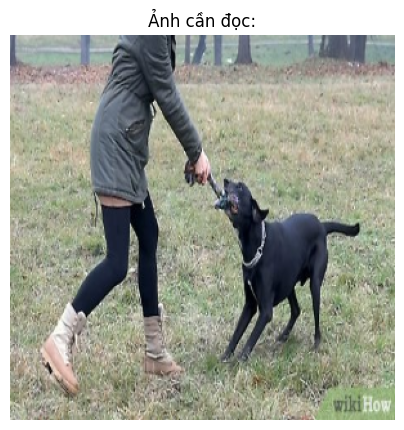

Ảnh đã sẵn sàng để đưa vào model.
Kích thước tensor cho model: (299, 299, 3)


In [49]:
import tensorflow as tf
import matplotlib.pyplot as plt

def load_va_tien_xu_ly_anh(path_anh, image_size):
    # Đọc ảnh
    img_raw = tf.io.read_file(path_anh)
    img_raw = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
    img_raw = tf.cast(img_raw, tf.float32)

    # Chuẩn hoá size
    if isinstance(image_size, (tuple, list)):
        h, w = int(image_size[0]), int(image_size[1])
    else:
        h, w = int(image_size), int(image_size)

    img_raw = tf.image.resize(img_raw, (h, w))

    # Bản để vẽ (0–1)
    img_show = img_raw / 255.0

    # Bản đưa vào model (preprocess EfficientNet)
    img_model = tf.keras.applications.efficientnet.preprocess_input(img_raw)

    return img_model, img_show


# =========================
# LOAD ẢNH NGOÀI
# =========================
IMAGE_PATH = "/kaggle/input/chotest/cho.jpg"  # path đúng của bạn
anh_ngoai, anh_de_xem = load_va_tien_xu_ly_anh(IMAGE_PATH, IMAGE_SIZE)

plt.figure(figsize=(5,5))
plt.imshow(anh_de_xem.numpy())
plt.axis("off")
plt.title("Ảnh cần đọc:")
plt.show()

print("Ảnh đã sẵn sàng để đưa vào model.")
print("Kích thước tensor cho model:", anh_ngoai.shape)


# TEST mô hình

In [50]:
import tensorflow as tf
import numpy as np

# =========================
# Cell này dùng để TEST mô hình Image Captioning bằng greedy decoding (argmax).
# Mục tiêu: từ 1 ảnh (đã tiền xử lý giống lúc train) -> sinh ra 1 câu caption.
#
# Các biến cần có sẵn trong notebook:
# - image_caption_model : mô hình đã build + compile + load weights
# - text_vectorization  : TextVectorization đã adapt trên caption
# - SEQ_LENGTH          : độ dài tối đa chuỗi token (bao gồm <start>, <end>)
#
# Lưu ý quan trọng:
# - Ảnh đưa vào model phải là ảnh đã preprocess (efficientnet.preprocess_input)
# - Ảnh dùng để hiển thị (0..1) như anh_de_xem chỉ để nhìn cho đẹp, không đưa vào model
# =========================


# =========================
# 1) Chuẩn bị vocab để đổi id <-> từ
# =========================
vocab = text_vectorization.get_vocabulary()
word_by_id = np.array(vocab)

# Tìm id của token đặc biệt <start> và <end>
try:
    start_id = int(np.where(word_by_id == "<start>")[0][0])
    end_id   = int(np.where(word_by_id == "<end>")[0][0])
except IndexError:
    print("Không tìm thấy <start> hoặc <end> trong vocabulary.")
    print("Bạn kiểm tra lại bước chuẩn hoá caption có thêm token <start> <end> chưa.")
    raise


# =========================
# 2) Hàm sinh caption greedy
# =========================
def sinh_caption_greedy_tu_tensor(anh_tensor, model, max_len=None):
    """
    SV note:
    - Greedy decoding: mỗi bước lấy token có xác suất cao nhất (argmax).
    - Input model: [image, decoder_input]
      + image: (1, H, W, C)
      + decoder_input: (1, SEQ_LENGTH-1)
    - Output: (1, SEQ_LENGTH-1, VOCAB_SIZE)
    """

    # max_len mặc định theo chiều dài decoder
    if max_len is None:
        max_len = SEQ_LENGTH - 1

    # Nếu ảnh chưa có batch dimension thì thêm vào
    # (trường hợp anh_tensor shape (H,W,C) -> (1,H,W,C))
    if len(anh_tensor.shape) == 3:
        anh = tf.expand_dims(anh_tensor, axis=0)
    else:
        # Nếu đã là batch (1,H,W,C) thì giữ nguyên
        anh = anh_tensor

    # decoder_input ban đầu toàn PAD=0, token đầu là <start>
    decoder_input = np.zeros((1, SEQ_LENGTH - 1), dtype=np.int32)
    decoder_input[0, 0] = start_id

    tokens_sinh = []

    # Lặp để sinh từng token tiếp theo
    for t in range(0, max_len - 1):
        # Dùng call trực tiếp để giảm overhead so với predict
        # training=False để đảm bảo inference mode
        du_doan = model([anh, decoder_input], training=False).numpy()

        # Lấy token có xác suất cao nhất tại vị trí t
        token_id = int(np.argmax(du_doan[0, t, :]))

        # Nếu gặp <end> thì dừng
        if token_id == end_id:
            break

        tokens_sinh.append(token_id)

        # Nhét token vừa sinh vào decoder_input để làm “ngữ cảnh” cho bước sau
        if (t + 1) < (SEQ_LENGTH - 1):
            decoder_input[0, t + 1] = token_id

    # Đổi token_id -> từ
    tu_sinh = [word_by_id[token_id] for token_id in tokens_sinh]

    # Lọc PAD/rỗng rồi ghép thành câu
    caption_text = " ".join([w for w in tu_sinh if w not in ["", "[PAD]"]])

    return caption_text, tokens_sinh


# =========================
# 3) THỰC THI TEST
# =========================
# 
# - Nếu bạn test ảnh ngoài: dùng anh_ngoai (ảnh đã preprocess)
# - Nếu bạn test ảnh lấy từ val_ds: dùng anh_test (thường cũng đã preprocess đúng pipeline)
#
# Không dùng anh_de_xem để sinh caption (anh_de_xem chỉ để hiển thị)
# =========================

# Đổi biến ảnh test ở đây cho đúng:
#   - ảnh ngoài (đã preprocess): anh_ngoai
#   - ảnh lấy từ val_ds: anh_test
anh_dung_de_test = anh_ngoai

caption_du_doan, token_ids = sinh_caption_greedy_tu_tensor(anh_dung_de_test, image_caption_model)

print("Caption dự đoán:")
print(caption_du_doan)


Caption dự đoán:
một con chó đang chơi với một con chó màu xanh và trắng


# Đánh giá Loss + Masked Accuracy (20 batch)

In [51]:
# ==========================================
# A) EVALUATE NHANH: Loss + Masked Accuracy
# ==========================================
EVAL_STEPS = 20   # tăng nếu muốn ổn định hơn, giảm nếu cần nhanh hơn

results = image_caption_model.evaluate(
    val_ds,
    steps=EVAL_STEPS,
    verbose=1
)

print("\n Kết quả evaluate (trên", EVAL_STEPS, "batches):")
for name, val in zip(image_caption_model.metrics_names, results):
    print(f"{name}: {val:.6f}")


20/20 [==============================] - 134s 6s/step - loss: 3.2630 - tinh_accuracy_co_mask: 0.4005

 Kết quả evaluate (trên 20 batches):
loss: 3.263031
tinh_accuracy_co_mask: 0.400487


# BLEU-1..4

In [52]:
# ==========================================
# B) BLEU-1..4 (NHANH) TRÊN 1 TẬP MẪU NHỎ
# ==========================================
import numpy as np
import tensorflow as tf

# 1) Import BLEU
try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
    _bleu_ok = True
except Exception as e:
    _bleu_ok = False
    print("Chưa có NLTK BLEU. Nếu cần, bạn chạy: !pip -q install nltk")

if not _bleu_ok:
    raise RuntimeError("Thiếu nltk. Cài nltk rồi chạy lại cell này.")

# 2) Chuẩn bị vocab -> id2word
vocab = text_vectorization.get_vocabulary()
word_by_id = np.array(vocab)

def _find_id(tok):
    idx = np.where(word_by_id == tok)[0]
    return int(idx[0]) if len(idx) else None

start_id = _find_id("<start>")
end_id   = _find_id("<end>")

def decode_token_ids(token_ids):
    """token_ids: list[int]"""
    words = []
    for tid in token_ids:
        if tid == 0:  # padding
            continue
        if end_id is not None and tid == end_id:
            break
        w = word_by_id[tid] if tid < len(word_by_id) else ""
        if w in ["<start>", "<end>", ""]:
            continue
        words.append(w)
    return " ".join(words)

# 3) Greedy caption (tương thích với model của bạn: inputs=[image, decoder_input])
@tf.function
def _forward(image_1, dec_in):
    return image_caption_model([image_1, dec_in], training=False)

def greedy_caption_one(image_tensor, max_len=20):
    """
    image_tensor: (H,W,C) đã preprocess giống dataset
    max_len: giới hạn số token sinh để chạy nhanh
    """
    if start_id is None:
        raise ValueError("Không tìm thấy <start> trong vocab. Bạn kiểm tra lại bước thêm <start>/<end>.")

    img = tf.expand_dims(image_tensor, 0)  # (1,H,W,C)
    dec = np.zeros((1, SEQ_LENGTH - 1), dtype=np.int32)
    dec[0, 0] = start_id

    out_tokens = []
    steps = min(max_len, SEQ_LENGTH - 1)

    for t in range(steps):
        logits = _forward(img, tf.convert_to_tensor(dec))   # (1, SEQ_LENGTH-1, vocab)
        next_id = int(tf.argmax(logits[0, t, :], axis=-1).numpy())

        if end_id is not None and next_id == end_id:
            break

        out_tokens.append(next_id)
        if t + 1 < (SEQ_LENGTH - 1):
            dec[0, t + 1] = next_id

    return decode_token_ids(out_tokens)

# 4) Tính BLEU trên tập mẫu nhỏ
NUM_SAMPLES = 128     
MAX_LEN_EVAL = 25     

smoothie = SmoothingFunction().method4
refs = []
hyps = []

count = 0
for (x, y) in val_ds:
    # x = (img_batch, decoder_input_batch), y = target_tokens_batch
    img_batch = x[0].numpy()         # (B,H,W,C)
    tgt_batch = y.numpy()            # (B, SEQ_LENGTH-1)

    B = img_batch.shape[0]
    for i in range(B):
        ref_text = decode_token_ids(tgt_batch[i].tolist())   # GT từ target_tokens
        hyp_text = greedy_caption_one(img_batch[i], max_len=MAX_LEN_EVAL)

        refs.append([ref_text.lower().split()])
        hyps.append(hyp_text.lower().split())

        count += 1
        if count >= NUM_SAMPLES:
            break
    if count >= NUM_SAMPLES:
        break

bleu1 = corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=smoothie)
bleu2 = corpus_bleu(refs, hyps, weights=(0.5,0.5,0,0), smoothing_function=smoothie)
bleu3 = corpus_bleu(refs, hyps, weights=(1/3,1/3,1/3,0), smoothing_function=smoothie)
bleu4 = corpus_bleu(refs, hyps, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie)

print(f" BLEU (N={NUM_SAMPLES}, max_len={MAX_LEN_EVAL})")
print("BLEU-1:", round(bleu1, 4))
print("BLEU-2:", round(bleu2, 4))
print("BLEU-3:", round(bleu3, 4))
print("BLEU-4:", round(bleu4, 4))


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
 BLEU (N=128, max_len=25)
BLEU-1: 0.2484
BLEU-2: 0.1514
BLEU-3: 0.0965
BLEU-4: 0.0605


# Đánh giá định tính

Đã gom được 300 ảnh để random.


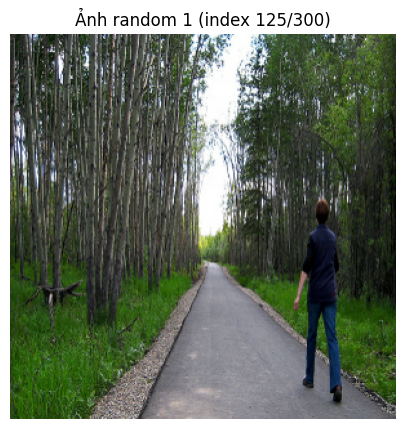

GT  : một người đi dọc con đường trải nhựa tránh xa máy ảnh xuyên qua một khu rừng
PRED: một người đàn ông đang đứng trên một con chó con chó đen


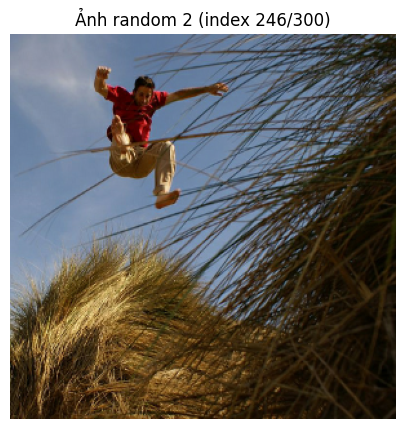

GT  : một người đàn ông mặc áo đỏ đang nhảy vào bãi cỏ cao
PRED: một người đàn ông đang đi bộ trên một ngọn đồi


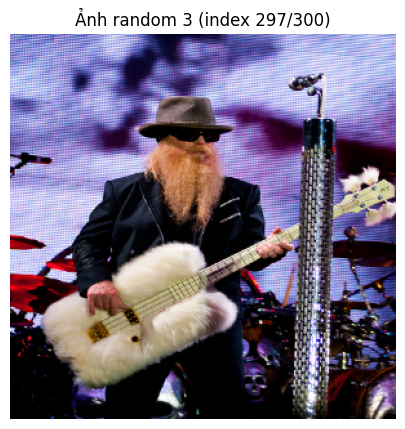

GT  : một người đàn ông có bộ râu dài đang chơi guitar
PRED: một người đàn ông mặc áo sơ mi trắng đang chơi guitar


In [62]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ============================================================
# SV note:
# - Mục tiêu: random 3 ảnh KHÁC NHAU từ 300 ảnh đầu của val_ds
# - val_ds có dạng: ((img, decoder_input), y_target)
# - img đã preprocess cho EfficientNet -> cần deprocess trước khi hiển thị
# - In kèm Ground Truth (GT) và caption dự đoán (PRED)
# ============================================================

# ----------------------------
# 1) Chuẩn bị vocab để decode token -> text
# ----------------------------
vocab = text_vectorization.get_vocabulary()
word_by_id = np.array(vocab)

def _find_id(tok):
    idx = np.where(word_by_id == tok)[0]
    return int(idx[0]) if len(idx) else None

start_id = _find_id("<start>")
end_id   = _find_id("<end>")

def decode_token_ids(token_ids):
    """
    Chuyển list token id -> câu tiếng Việt
    (bỏ padding + <start>/<end>)
    """
    words = []
    for tid in token_ids:
        if tid == 0:  # padding
            continue
        if end_id is not None and tid == end_id:
            break
        w = word_by_id[tid] if tid < len(word_by_id) else ""
        if w in ["<start>", "<end>", ""]:
            continue
        words.append(w)
    return " ".join(words)

# ----------------------------
# 2) Deprocess ảnh để hiển thị đẹp
# ----------------------------
def deprocess_for_show(img_np):
    """
    Đưa ảnh về [0,1] bằng min-max normalize để plt.imshow không bị lỗi màu.
    """
    img = img_np.astype(np.float32)
    mn, mx = img.min(), img.max()
    if mx - mn < 1e-6:
        return np.zeros_like(img, dtype=np.float32)
    img01 = (img - mn) / (mx - mn)
    return np.clip(img01, 0.0, 1.0)

# ----------------------------
# 3) Greedy decoding (phù hợp model nhận [image, decoder_input])
# ----------------------------
@tf.function
def _forward(image_1, dec_in):
    return image_caption_model([image_1, dec_in], training=False)

def greedy_caption_one(image_tensor, max_len=25):
    """
    Sinh caption cho 1 ảnh bằng greedy decoding.
    """
    if start_id is None:
        raise ValueError("Không tìm thấy <start> trong vocab.")

    img = tf.expand_dims(image_tensor, 0)  # (1,H,W,C)
    dec = np.zeros((1, SEQ_LENGTH - 1), dtype=np.int32)
    dec[0, 0] = start_id

    out_tokens = []
    steps = min(max_len, SEQ_LENGTH - 1)

    for t in range(steps):
        logits = _forward(img, tf.convert_to_tensor(dec))
        next_id = int(tf.argmax(logits[0, t, :], axis=-1).numpy())

        if end_id is not None and next_id == end_id:
            break

        out_tokens.append(next_id)
        if t + 1 < (SEQ_LENGTH - 1):
            dec[0, t + 1] = next_id

    return decode_token_ids(out_tokens)

# ============================================================
# 4) Gom 300 ảnh đầu của val_ds -> random chọn 3 ảnh
# ============================================================
POOL_N = 300
RANDOM_K = 3
MAX_LEN_PRED = 25

# Lấy (img, y) rồi unbatch để mỗi phần tử là 1 ảnh
ds_pool = val_ds.map(lambda x, y: (x[0], y)).unbatch().take(POOL_N)

pool = []
for img, y in ds_pool:
    pool.append((img, y))

print("Đã gom được", len(pool), "ảnh để random.")

if len(pool) < RANDOM_K:
    raise ValueError("Không đủ ảnh trong pool để random.")

# Random K chỉ số KHÁC NHAU
indices = np.random.choice(len(pool), size=RANDOM_K, replace=False)

# ============================================================
# 5) Hiển thị 3 ảnh + GT + PRED
# ============================================================
for i, idx in enumerate(indices, start=1):
    img, y = pool[idx]

    img_np = img.numpy()
    y_np = y.numpy()

    gt = decode_token_ids(y_np.tolist())
    pred = greedy_caption_one(img, max_len=MAX_LEN_PRED)

    plt.figure(figsize=(7,5))
    plt.imshow(deprocess_for_show(img_np))
    plt.axis("off")
    plt.title(f"Ảnh random {i} (index {idx+1}/{len(pool)})")
    plt.show()

    print("GT  :", gt)
    print("PRED:", pred)
    print("=" * 110)
